In [1]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit import transpile
from qiskit.visualization import plot_histogram
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

In [2]:
#load image
def load_image(filename):
    im = Image.open(filename,'r')
    im = im.convert('L') #convert to grayscale
    return np.array(im)

In [162]:
def add_180_asymmetry_subtraction(qc, num_spatial_qubits):
    """
    Applies destructive interference to subtract a 180-degree rotated 
    version of a QPIE image from the original image. Modifies circuit in-place.
    
    Args:
        qc (QuantumCircuit): Your existing circuit with the image encoded.
        num_spatial_qubits (int): Total qubits used for the image (e.g., 10 for 32x32).
    """
    # 1. Add 1 Ancilla Qubit to control the interference
    anc_reg = QuantumRegister(1, 'asym_180_anc')
    qc.add_register(anc_reg)
    
    # Get the index of the newly added ancilla
    anc_idx = qc.num_qubits - 1 
    
    # 2. Create Superposition
    # Splits the universe: Ancilla |0> = Original, Ancilla |1> = Rotated
    qc.h(anc_idx)
    
    # 3. The Controlled 180-Degree Rotation
    # By applying a CNOT from the ancilla to EVERY spatial qubit, 
    # we effectively flip both the X and Y coordinate axes simultaneously.
    for q in range(num_spatial_qubits):
        qc.cx(anc_idx, q) 
        
    # 4. The Interference
    # Forces the original and rotated states to collide
    qc.h(anc_idx)
    
    return qc

In [3]:
#encode image into quantum state
def encode_image(filename, n_qubits):
    #open image file in greyscale and form normalized array
    pixel_value_array = load_image(filename).flatten()
    
    #Normalize the pixel values
    norm = np.linalg.norm(pixel_value_array)
    norm_array = pixel_value_array/norm


    #translate normalized array into qubits by assigning each pixel value to the amplitude of a quantum state
    
    qc = QuantumCircuit(n_qubits)
    qc.initialize(norm_array, qc.qubits)
    return qc,norm_array
    

In [188]:
def measure_image(qc, original_n_qubits, shots=10000, rgb=True, get_added_state=False):
    """
    Measures a QPIE image circuit. Automatically handles standard circuits 
    as well as circuits with added ancilla qubits for filtering.
    """
    # 1. Execute the circuit
    # Only append measure_all if the circuit doesn't already have measurements
    if not qc.cregs:
        qc.measure_all()
        
    aer_sim = AerSimulator()
    t_qc = transpile(qc, aer_sim, optimization_level=3)
    result = aer_sim.run(t_qc, shots=shots).result()
    counts = result.get_counts()
    num_ancillas = qc.num_qubits - original_n_qubits
    
    # --- NEW LOGIC: Determine the target ancilla flag ---
    if num_ancillas > 0:
        if get_added_state:
            # Interference ancilla (leftmost) is '0', all other filter ancillas are '1'
            success_flag = '0' + '1' * (num_ancillas - 1)
        else:
            # Default: all ancillas must be '1' (Subtracted state)
            success_flag = '1' * num_ancillas
    else:
        success_flag = ''

    # --- DIAGNOSTIC PRINT ---
    if num_ancillas > 0:
        successful_shots = sum([count for state, count in counts.items() 
                                if state.replace(' ', '')[:num_ancillas] == success_flag])
        print(f"--- FILTER DIAGNOSTICS ---")
        print(f"Total Shots Fired: {shots}")
        # Updated to show exactly which flag it successfully isolated
        print(f"Successful '{success_flag}' Measurements: {successful_shots}")
        print(f"Retention Rate: {(successful_shots / shots) * 100:.2f}%")
        if successful_shots < 2000:
            print("WARNING: Too few successful shots to reconstruct a clean image. Image will be extremely noisy.")
        print(f"--------------------------")

    # 2. Construct measured image array based ONLY on the original image size
    measured_arr = np.zeros(2**original_n_qubits, dtype=float)

    # 3. Parse the counts dictionary dynamically
    for state, count in counts.items():
        # Remove spaces in case Qiskit formats the output with registers
        state = state.replace(' ', '')
        
        # In Qiskit, qubits added last (the ancillas) are the leftmost bits
        ancilla_bits = state[:num_ancillas] if num_ancillas > 0 else ''
        img_bits = state[num_ancillas:]

        # Record amplitude if it's a raw image, OR if the target state succeeded
        if ancilla_bits == success_flag or num_ancillas == 0:
            idx = int(img_bits, 2)
            measured_arr[idx] = count / shots

    # Convert probability to amplitude
    measured_arr = np.sqrt(measured_arr)

    # 4. Convert back into RGB (0-255 scaling)
    if rgb:
        max_val = np.max(measured_arr)
        if max_val > 0: # Prevent division by zero if no shots succeeded
            measured_arr = (measured_arr * 255) / max_val
        
    # Dynamically reshape into a square grid
    size = int(np.sqrt(2**original_n_qubits))
    measured_arr = measured_arr.reshape((size, size))
    
    return measured_arr

In [297]:
def apply_gaussian_filter(qc, sigma=1.5):
    n_img_qubits = qc.num_qubits
    half_n = n_img_qubits // 2
    
    anc_reg = QuantumRegister(2, 'anc')
    qc.add_register(anc_reg)
    
    # FIX 1: Remove approximation_degree for 5-qubit registers
    qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")
    
    qc.append(qft_gate, range(half_n))
    qc.append(qft_gate, range(half_n, n_img_qubits))
    
    # FIX 2: Expand the frequency window to smooth the cutoff
    target_k_values = [0, 1, 2, 3, 4, 5, -1, -2, -3, -4, -5]
    target_frequencies = {}
    
    for k in target_k_values:
        val = k if k >= 0 else (2**half_n) + k
        bin_state = format(val, f'0{half_n}b')
        target_frequencies[bin_state] = k

    def apply_1d_filter(target_reg_start, anc_idx, spatial_sigma):
        for bin_state, k in target_frequencies.items():
            # 1. Calculate N (the width of the grid in pixels)
            N = 2 ** half_n 
            
            # 2. Convert the physical SciPy sigma into the Quantum wave sigma
            sigma_qc = (2 * np.pi / N) * spatial_sigma
            
            # 3. Calculate the weight using the corrected quantum sigma
            weight = np.exp(-(k**2 * sigma_qc**2) / 2)
            # Clamp weight to avoid domain errors in arcsin
            weight = max(0.0, min(1.0, weight)) 
            theta = 2 * np.arcsin(weight)
            
            mcry = RYGate(theta).control(half_n, ctrl_state=bin_state)
            qubit_targets = list(range(target_reg_start, target_reg_start + half_n)) + [n_img_qubits + anc_idx]
            qc.append(mcry, qubit_targets)

    apply_1d_filter(0, 0,sigma)
    apply_1d_filter(half_n, 1,sigma)
    
    iqft_gate = qft_gate.inverse()
    qc.append(iqft_gate, range(half_n))
    qc.append(iqft_gate, range(half_n, n_img_qubits))
    
    return qc

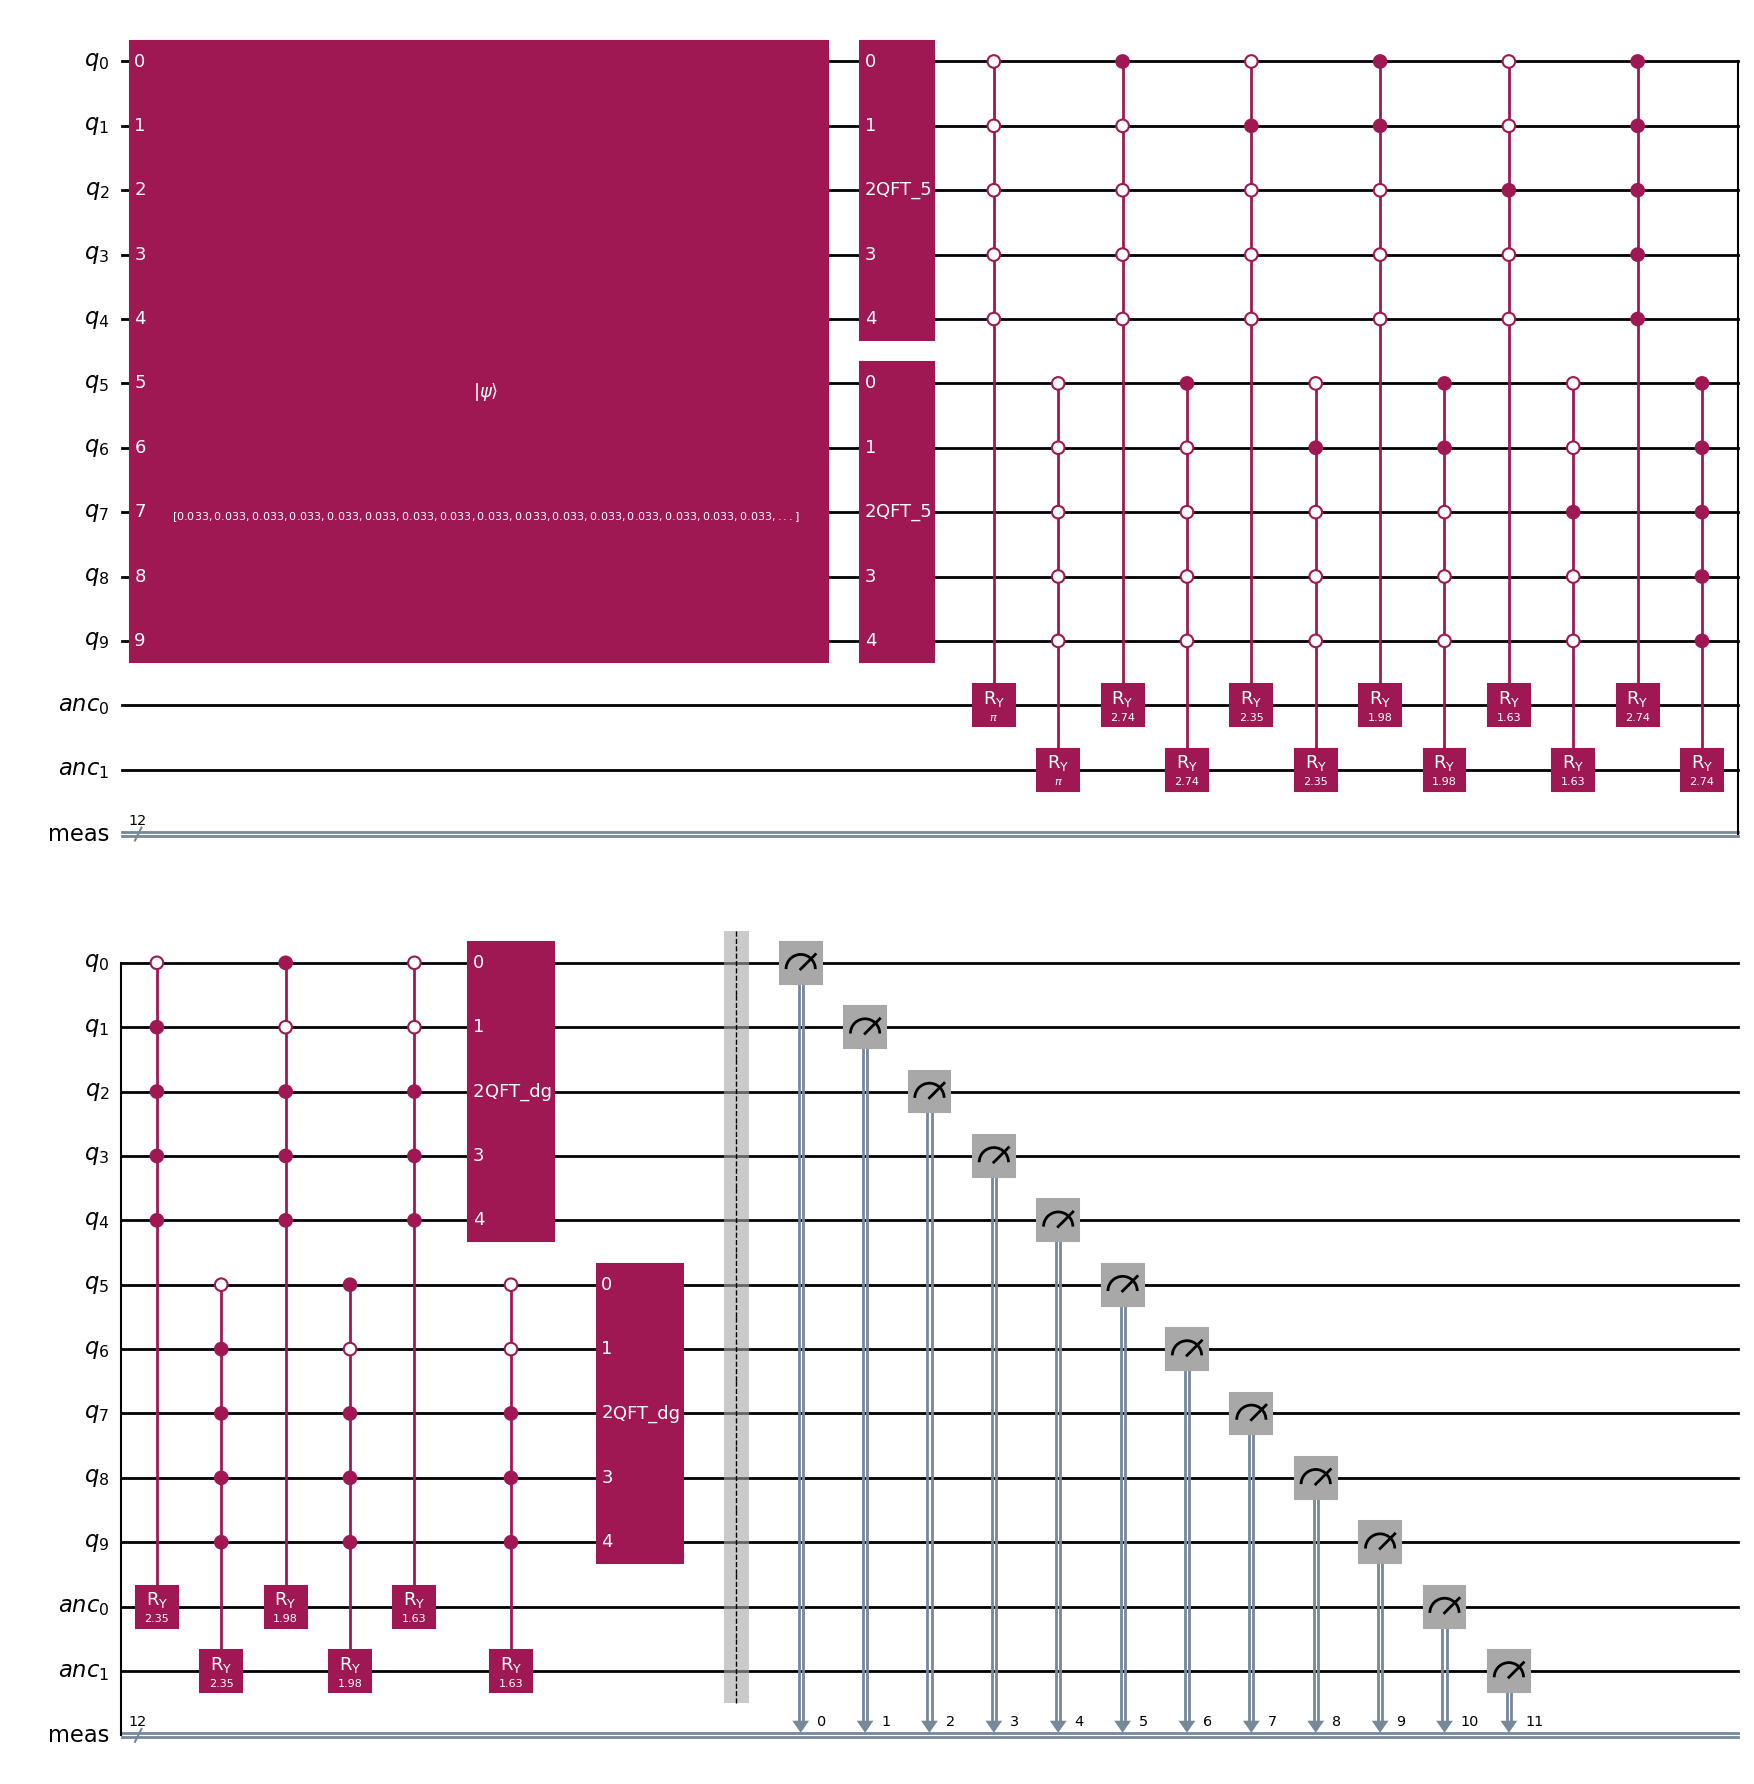

In [59]:
qc.draw('mpl')

C:\Users\benz5\AppData\Local\Temp\ipykernel_2132\2063306778.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")


--- FILTER DIAGNOSTICS ---
Total Shots Fired: 1000
Successful '11' Measurements: 444
Retention Rate: 44.40%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 10000
Successful '11' Measurements: 4356
Retention Rate: 43.56%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 43491
Retention Rate: 43.49%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 1000000
Successful '11' Measurements: 435653
Retention Rate: 43.57%
--------------------------


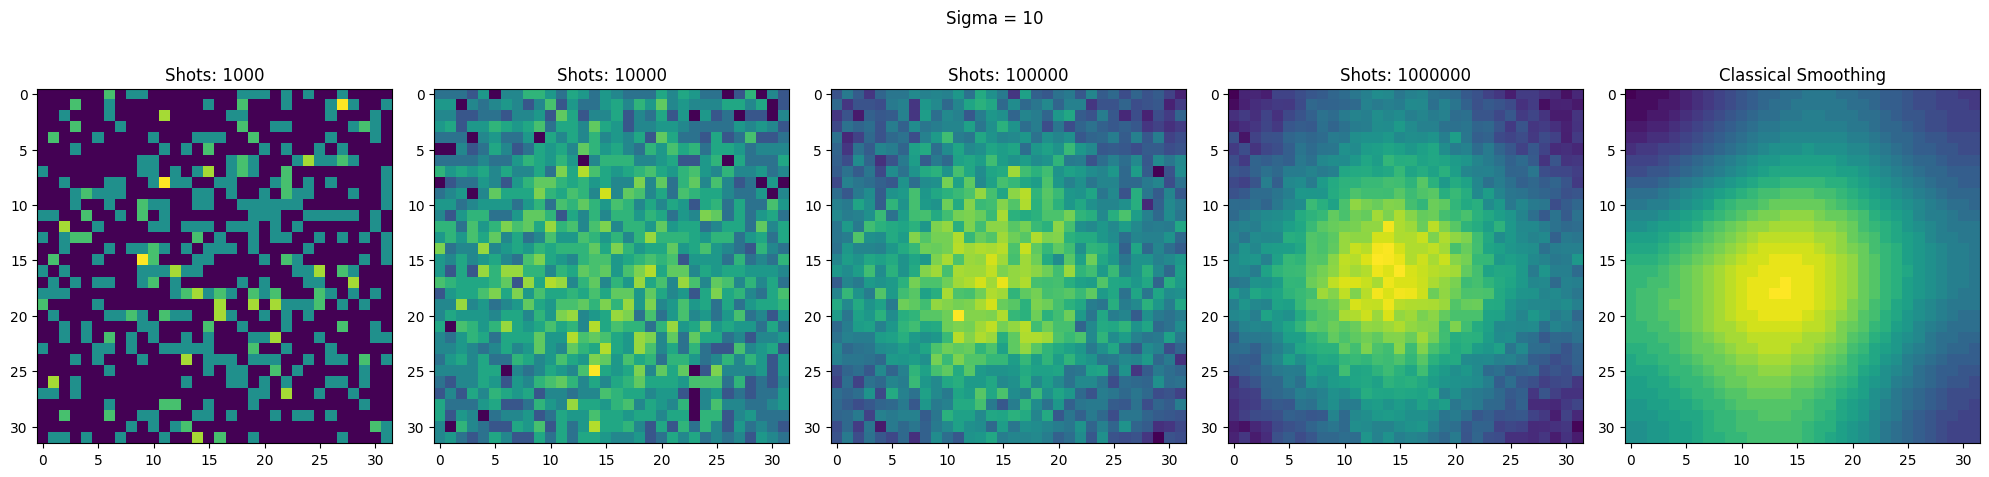

In [160]:
from scipy.ndimage import gaussian_filter

shots = [1000,10000,100000,1000000]

sigma = 10

fig, axs = plt.subplots(1, 5, figsize=(20, 5)) 

for i, ax in enumerate(axs): # Using axs directly is cleaner
    if i < 4:
        qc,norm_arr = encode_image('test_galaxy_32.png', 10)
        qc = apply_gaussian_filter(qc, sigma=sigma)
        qc = add_180_asymmetry_subtraction(qc,10)
        blurred_image_array = measure_image(qc, original_n_qubits=10, shots=shots[i])
        im_plot = ax.imshow(blurred_image_array)
        ax.set_title(f'Shots: {shots[i]}')
    else:
        image = load_image('test_galaxy_32.png')
        result = gaussian_filter(image, sigma=sigma)
        im_plot = ax.imshow(result)
        ax.set_title('Classical Smoothing')

    # 4. Add colorbar to each subplot
    #fig.colorbar(im_plot, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Sigma = {sigma}')
plt.tight_layout()
plt.show()


In [286]:
image = load_image('test_galaxy_32.png')
result = gaussian_filter(image, sigma=sigma).astype(float)
rot180 = np.rot90(result, k=2)
A2 = np.nansum(np.abs(result - rot180)) / (2*np.nansum(result))

In [284]:
#for A_mod calculation

from scipy.ndimage import gaussian_filter, rotate

shots = [100,1000,10000,100000,1000000]

sigma = 5

a_list = []

for i in range(len(shots)):
    qc,norm_arr = encode_image('test_galaxy_32.png', 10)
    qc = apply_gaussian_filter(qc, sigma=sigma)
    og = measure_image(qc, original_n_qubits=10, shots=shots[i])
    
    '''qc,norm_arr = encode_image('test_galaxy_32.png', 10)
    qc = apply_gaussian_filter(qc, sigma=sigma)
    qc = add_180_asymmetry_subtraction(qc,10)
    sub = measure_image(qc, original_n_qubits=10, shots=shots[i])'''
    
    rot180 = np.rot90(og, k=2)
    a_list.append(np.nansum(np.abs(og-rot180)) / (2*np.nansum(og)))
    #a_list.append(np.nansum(sub) / (2*np.nansum(og)))
    

C:\Users\benz5\AppData\Local\Temp\ipykernel_2132\2063306778.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")


--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100
Successful '11' Measurements: 59
Retention Rate: 59.00%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 1000
Successful '11' Measurements: 585
Retention Rate: 58.50%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 10000
Successful '11' Measurements: 5704
Retention Rate: 57.04%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 57396
Retention Rate: 57.40%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 1000000
Successful '11' Measurements: 576661
Retention Rate: 57.67%
--------------------------


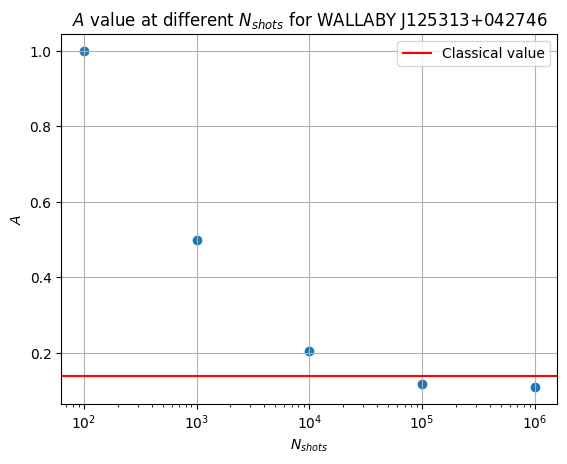

In [301]:
plt.title(r'$A$ value at different $N_{shots}$ for WALLABY J125313+042746')
plt.scatter(shots,a_list)
plt.axhline(A2,label='Classical value',c='red')
plt.xscale('log')
plt.xlabel(r'$N_{shots}$')
plt.ylabel(r'$A$')
plt.legend()
plt.grid()

In [305]:
#A calculation for various smoothings

smoothings = np.linspace(0,6,num=100)
classical_a = []

for smooth in smoothings:
    image = load_image('test_galaxy_32.png')
    result = gaussian_filter(image, sigma=smooth).astype(float)
    rot180 = np.rot90(result, k=2)
    classical_a.append(np.nansum(np.abs(result - rot180)) / (2*np.nansum(result)))


smoothings2 = np.linspace(0,6,7)
quantum_a = []
for smooth in smoothings2:
    x = []
    for i in range(5):
        qc,norm_arr = encode_image('test_galaxy_32.png', 10)
        qc = apply_gaussian_filter(qc, sigma=smooth)
        og = measure_image(qc, original_n_qubits=10, shots=100000)    
        rot180 = np.rot90(og, k=2)
        x.append(np.nansum(np.abs(og-rot180)) / (2*np.nansum(og)))
    quantum_a.append(x)
    

C:\Users\benz5\AppData\Local\Temp\ipykernel_2132\234085890.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")


--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 99936
Retention Rate: 99.94%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 99941
Retention Rate: 99.94%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 99932
Retention Rate: 99.93%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 99927
Retention Rate: 99.93%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 99937
Retention Rate: 99.94%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 95667
Retention Rate: 95.67%
--------------------------
--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 95644
Retention Rate: 95.64%
--------------------------
--- FILTER DIAGNOSTICS ---


<ErrorbarContainer object of 3 artists>

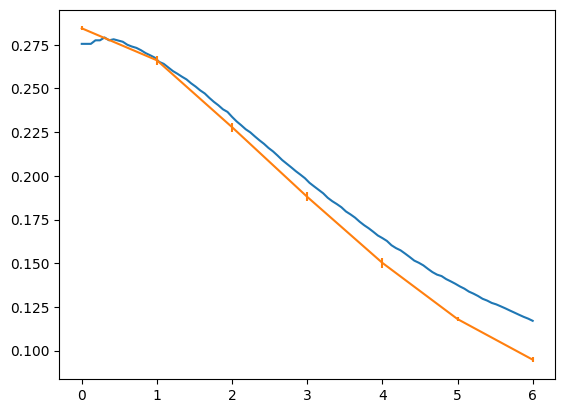

In [306]:
plt.plot(smoothings, classical_a)

quantum_avg = np.average(quantum_a, axis=1)
error = np.std(quantum_a, axis=1)
plt.errorbar(smoothings2, quantum_avg, yerr=error)

In [304]:
error

array([0.00045901, 0.00064053, 0.0006718 , 0.00096213, 0.00072852,
       0.00065722, 0.00049095])

C:\Users\benz5\AppData\Local\Temp\ipykernel_2132\2063306778.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")


--- FILTER DIAGNOSTICS ---
Total Shots Fired: 1000000
Successful '11' Measurements: 42800
Retention Rate: 4.28%
--------------------------


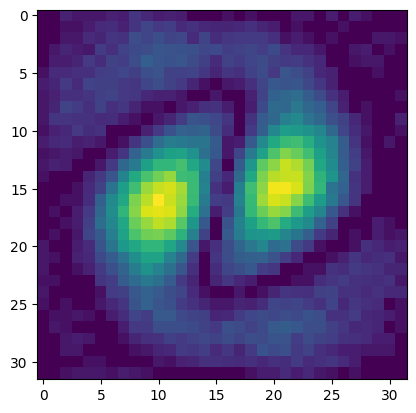

In [165]:
qc,norm_arr = encode_image('test_galaxy_32.png', 10)
qc = apply_gaussian_filter(qc, sigma=2)
add_180_asymmetry_subtraction(qc,10)

final_image = measure_image(qc, original_n_qubits=10, shots=1000000)
plt.imshow(final_image)

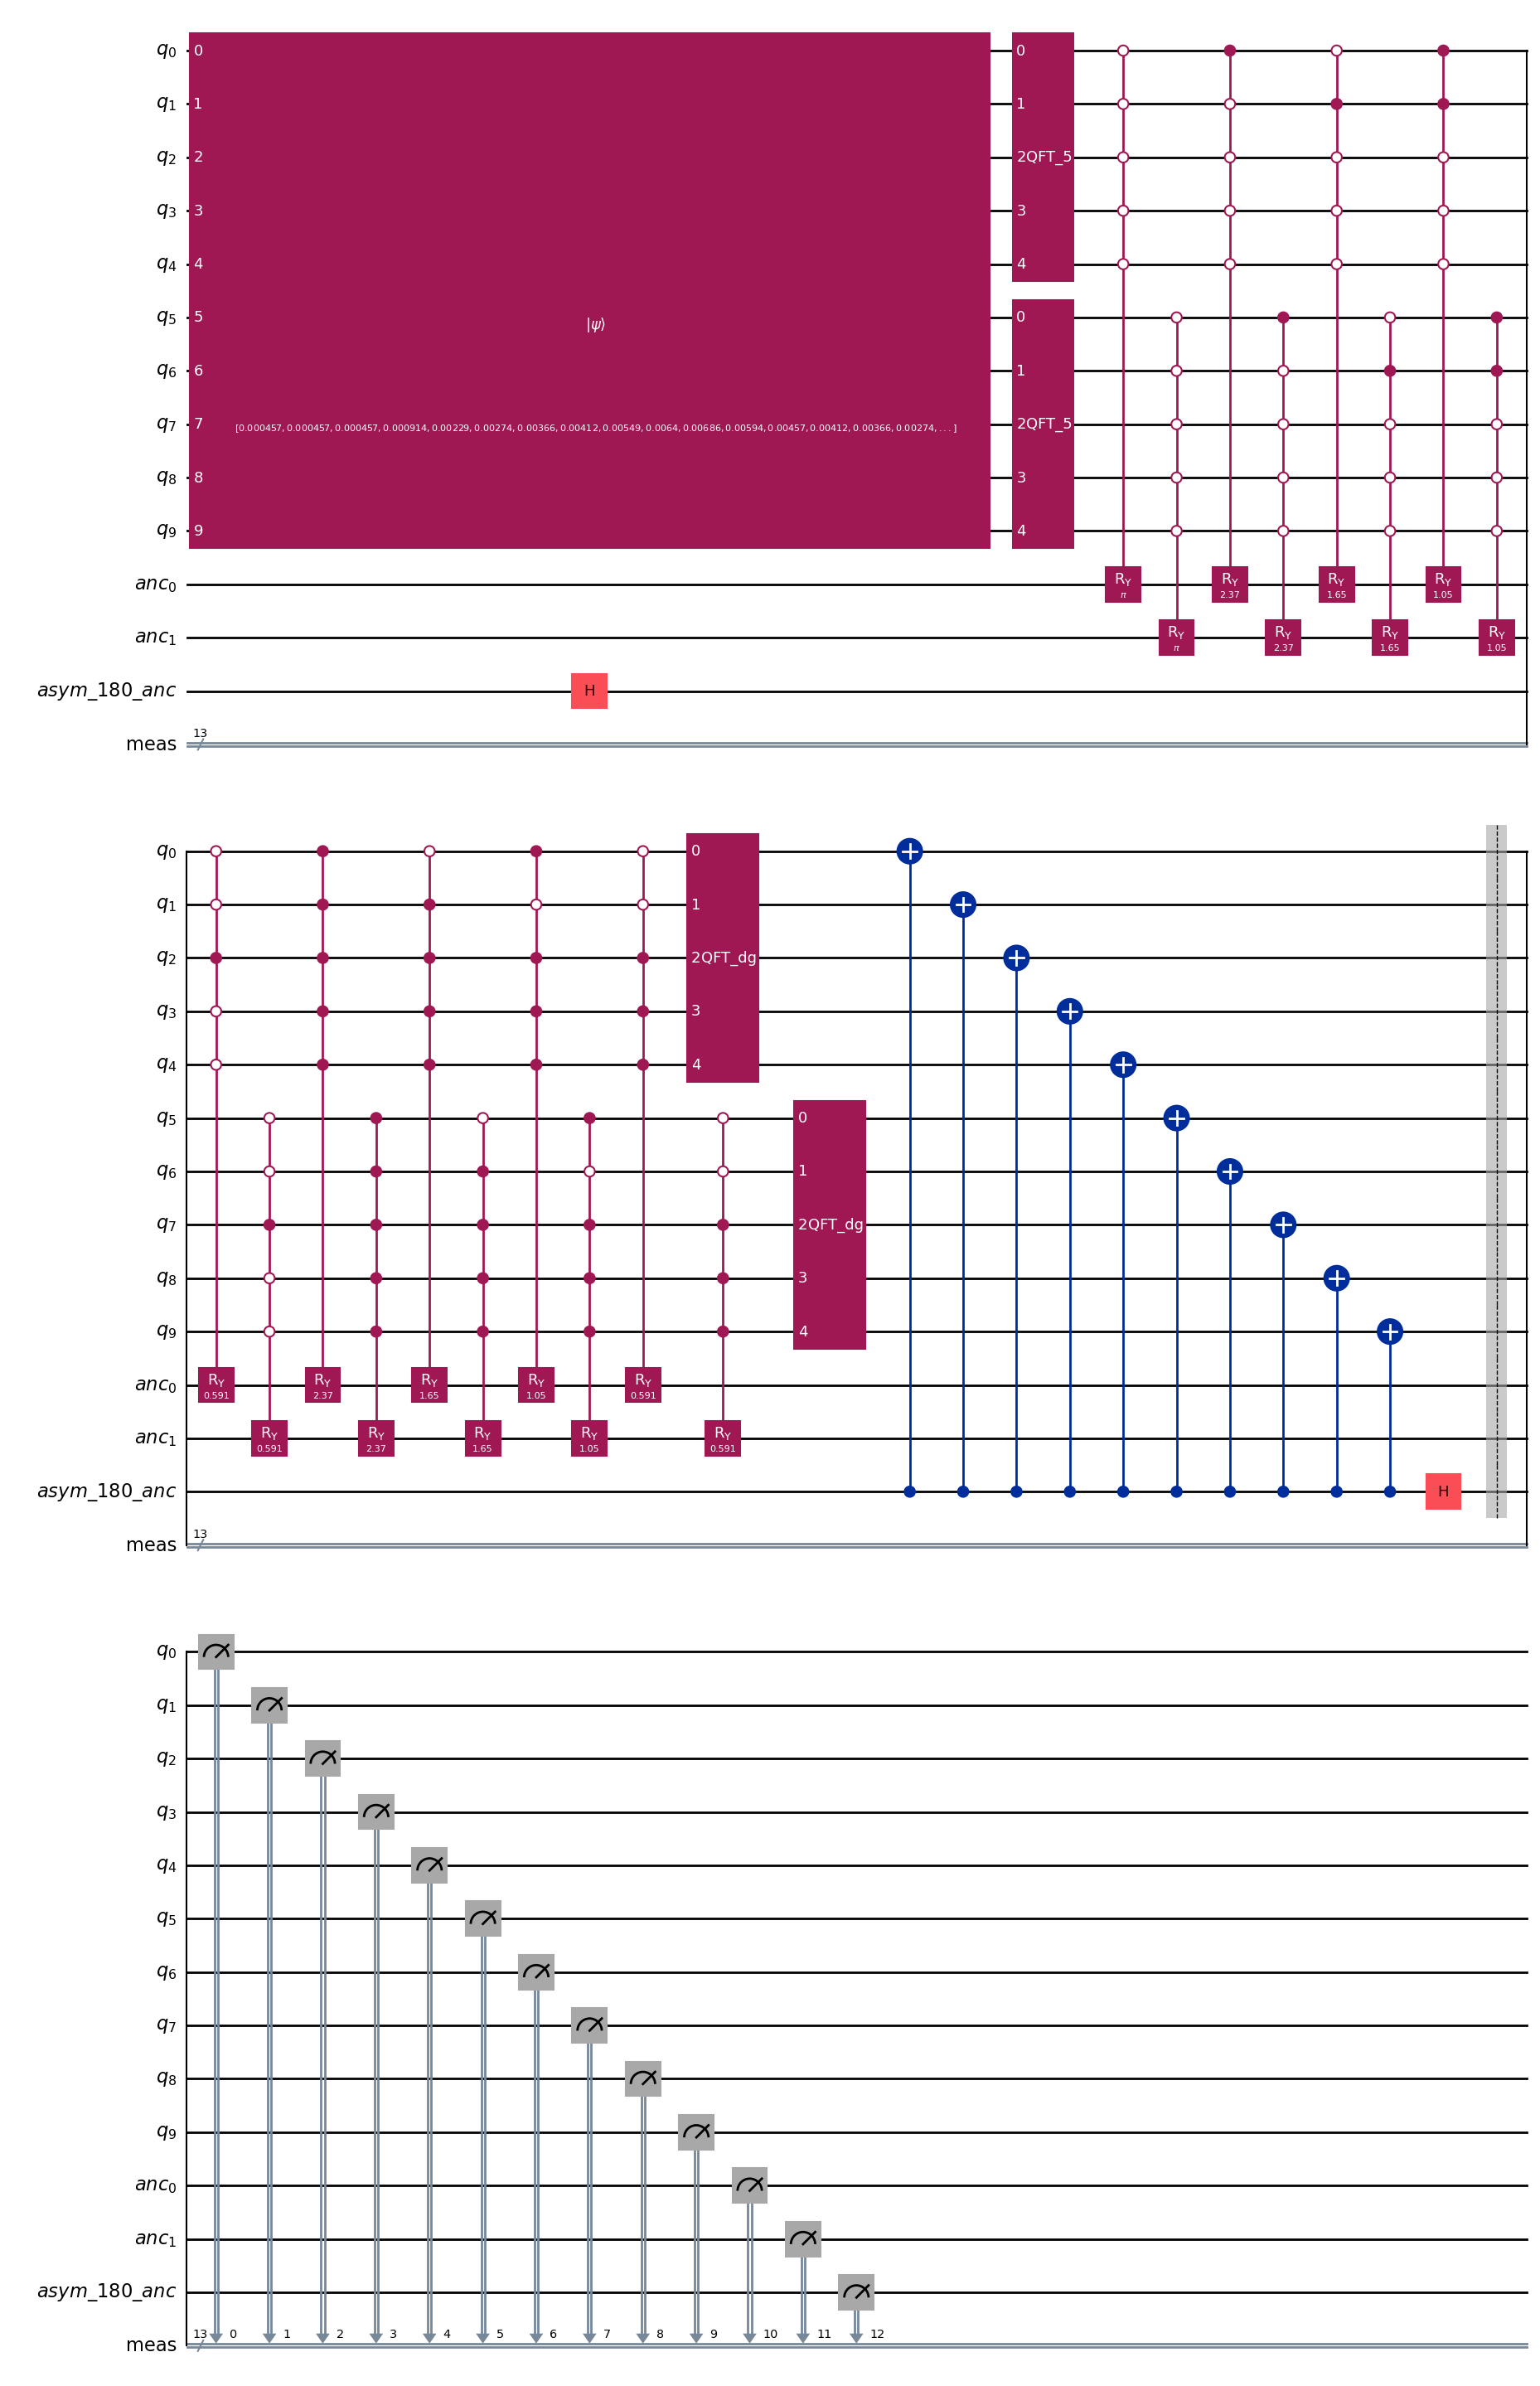

In [166]:
qc.draw('mpl')

In [5]:
def semi_classical_QFT(n,qc):
    qr = QuantumRegister(n, 'q')
    cr = ClassicalRegister(n, 'c')
    
    qc.x(0)
    qc.barrier()
    
    for i in range(n - 1, -1, -1):
        qc.h(qr[i])
        qc.measure(qr[i], cr[i])
        
        for j in range(i - 1, -1, -1):
            phase_angle = np.pi / (2 ** (i - j))
            
            # Modern Qiskit 1.0+ syntax for classically conditioned gates
            with qc.if_test((cr[i], 1)):
                qc.p(phase_angle, qr[j])
                        
        qc.barrier()
        
    return qc

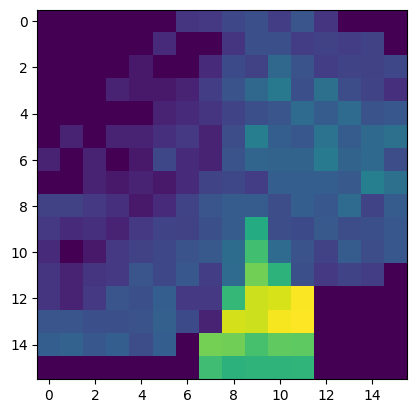

In [13]:
#try to flip image

c = 1e-8 #to avoid log(0) error when plotting
qc,norm_arr = encode_image('cake-large.png', 8)

qc.x(range(8))
measured_arr = measure_image(qc, shots = 5000)

plt.imshow(measured_arr)




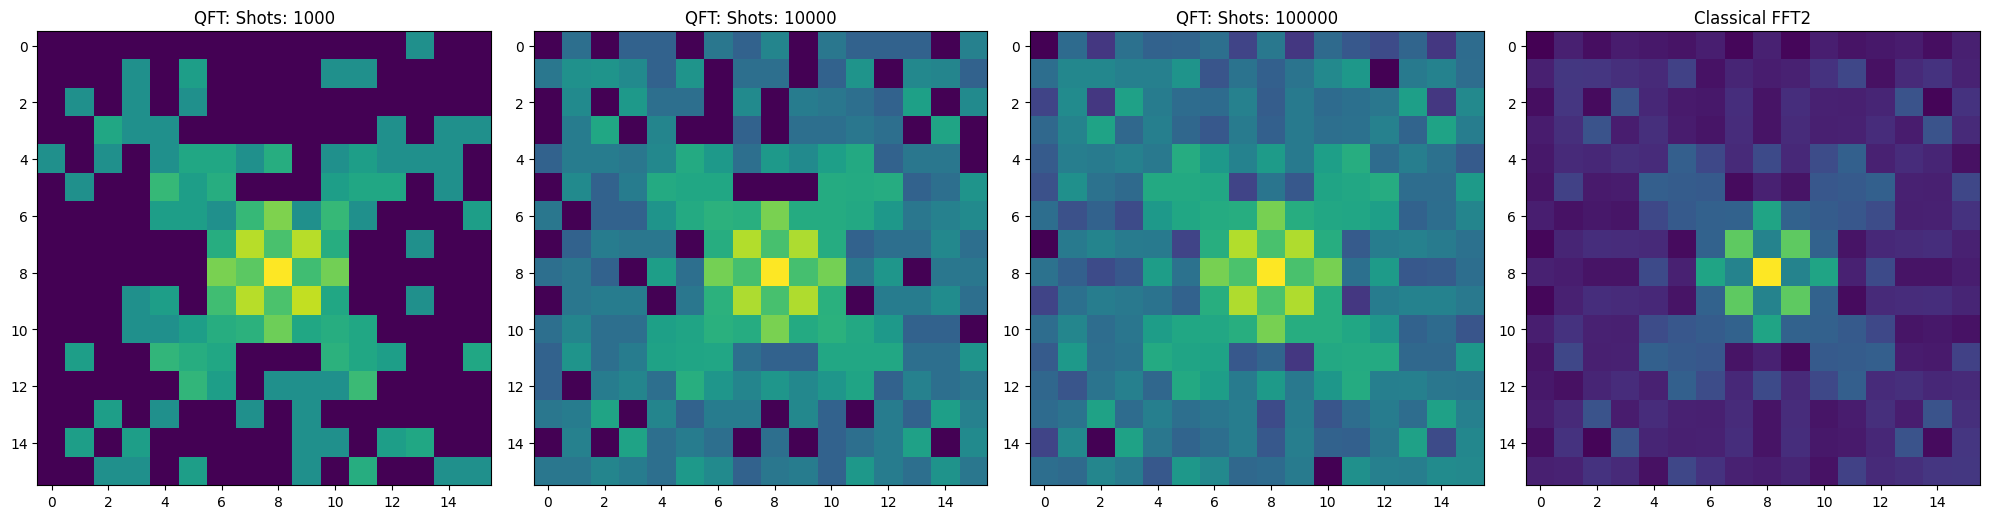

In [118]:
# 1. Define bounds for consistent color scaling
# Adjust these based on your data's expected range
v_min = 1e-2
v_max = 1e4

# 2. Increase figsize for bigger plots (width, height in inches)
fig, axs = plt.subplots(1, 4, figsize=(20, 5)) 

shots = np.array([1000, 10000, 100000])

for i, ax in enumerate(axs): # Using axs directly is cleaner
    if i < 3:
        qc, norm_arr = encode_image('circle.png', 8)
        qc.append(QFTGate(4), range(4))
        qc.append(QFTGate(4), range(4,8))
        measured_arr = measure_image(qc, 8, shots=shots[i])
        shifted_image = np.fft.fftshift(measured_arr)
        im_plot = ax.imshow(np.log1p(shifted_image))
        ax.set_title(f'QFT: Shots: {shots[i]}')
    else:
        # Classical FT
        im = load_image('circle.png')
        norm = np.linalg.norm(im)
        norm_array = im/norm
        f_transform = np.fft.fft2(norm_array)
        f_shift = np.fft.fftshift(f_transform)
        magnitude_spectrum = np.abs(f_shift)
        im_plot = ax.imshow(np.log1p(magnitude_spectrum))
        ax.set_title('Classical FFT2')

    # 4. Add colorbar to each subplot
    #fig.colorbar(im_plot, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

1. fourier space
2. putting into the program + processing
3. limit to qubits
4. how to correlate the data between the opposite sides of the spectrum
5. More examples - real data

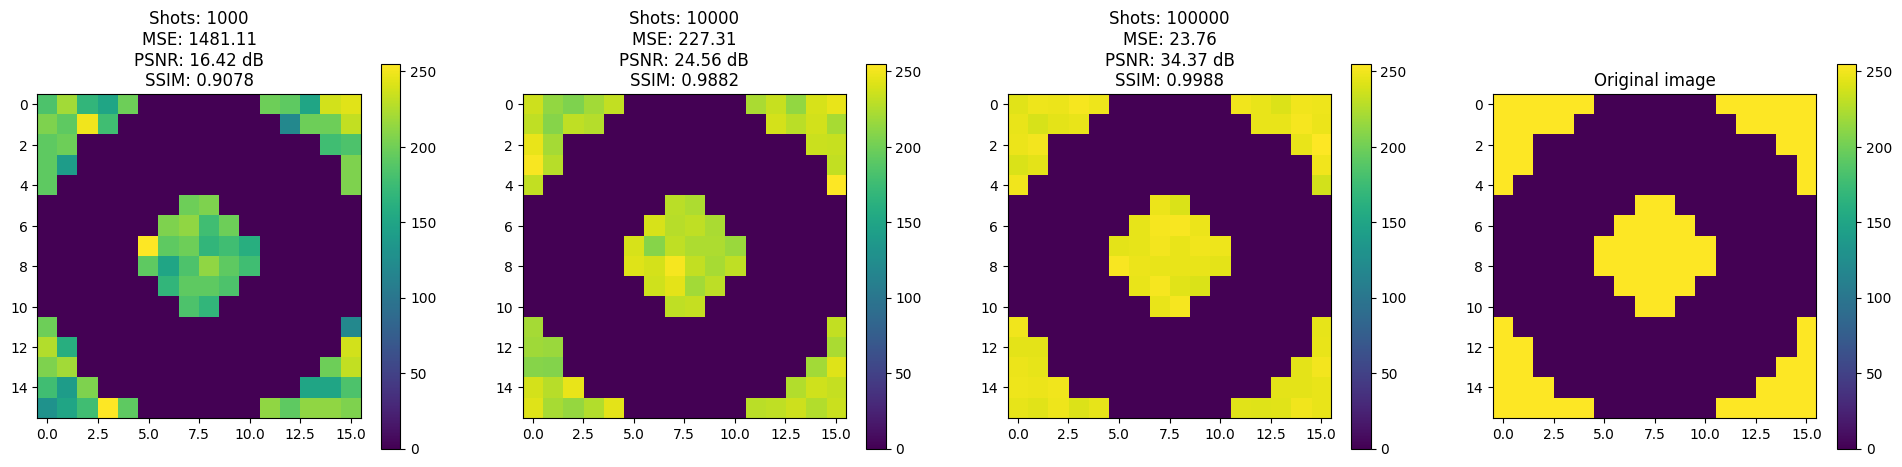

In [121]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# transform to the spatial domain
# inverse QFT
magnitude_spectrum = load_image('circle.png')

plt.figure(figsize=(24, 5))
plt.subplot(1, len(shots) + 1, len(shots) + 1)
plt.imshow(magnitude_spectrum)
plt.colorbar()
plt.title('Original image')
for i in range(len(shots)):
    qc,norm_arr = encode_image('circle.png', 8)
    #qc.append(QFTGate(8), qc.qubits)
    #qc.append(QFTGate(8).inverse(), qc.qubits)
    measured_arr = measure_image(qc, 8, shots = shots[i])
    # calculate the mean squared error
    mse = np.mean((measured_arr - magnitude_spectrum) ** 2)
    psnr_val = 10 * np.log10((255 ** 2) / mse)
    ssim_val = ssim(magnitude_spectrum, measured_arr, data_range=255)

    # shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(1, len(shots)+1, i + 1)
    plt.imshow(measured_arr)
    plt.colorbar()
    plt.title(f"Shots: {shots[i]}\n"
                 f"MSE: {mse:.2f}\n"
                 f"PSNR: {psnr_val:.2f} dB\n"
                 f"SSIM: {ssim_val:.4f}")
        

plt.show()

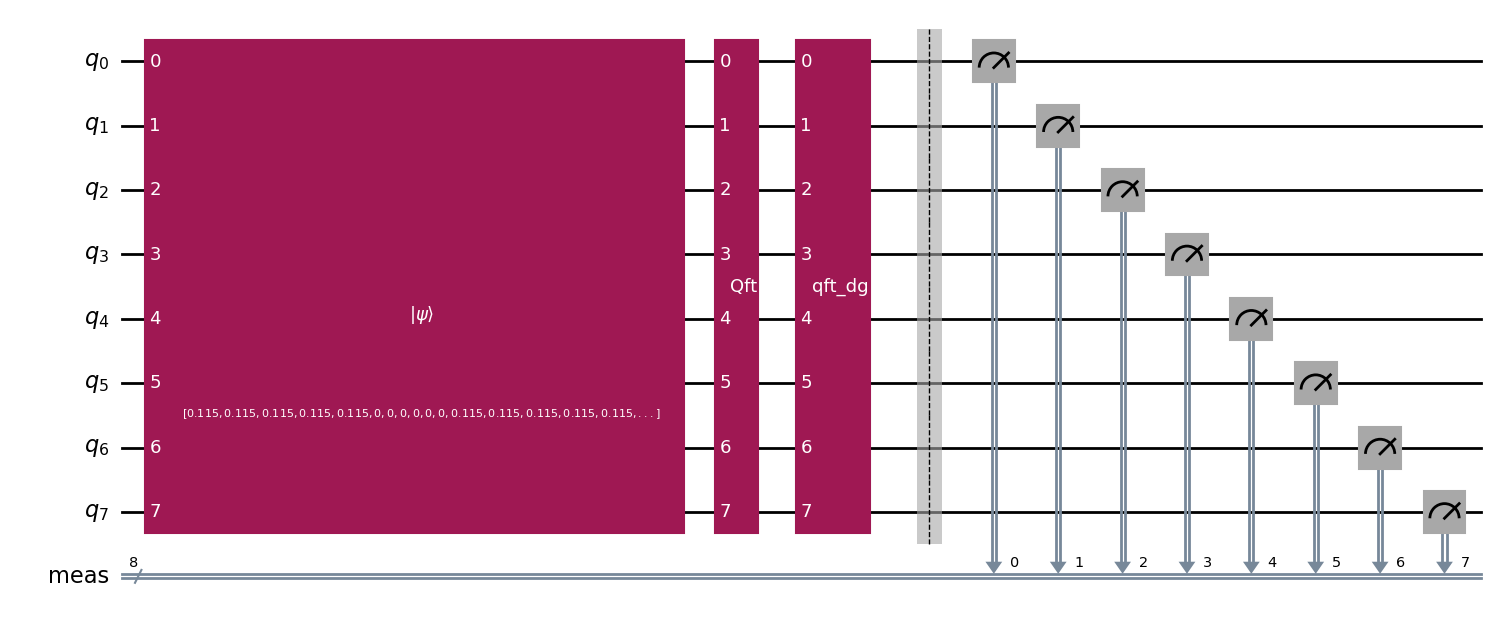

In [ ]:
qc.draw('mpl')

### Quantum advantage
Less time, less energy, more accurate results (mean squared error?).
Scalability, compilability, connectivity, robustness, parallelizability.
https://arxiv.org/pdf/2303.02138

### Questions
1. Should we write down the circuits by hand from the simplest gates?

### Next steps
1. Make decoding.
2. Apply kernles in fourier domain.
3. Try colored images.
4. Measure quantum advantage.